# Application Pratique des Réseaux de Neurones

Ce notebook accompagne le document théorique et propose une progression allant de l'implémentation manuelle (NumPy) à l'utilisation de frameworks modernes (TensorFlow/Keras).

## 1. Installation et Imports

Nous commençons par importer les bibliothèques nécessaires pour le calcul numérique, la visualisation et l'apprentissage profond.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

print('TensorFlow version:', tf.__version__)

TensorFlow version: 2.21.0


## 2. Niveau Débutant : Réseau manuel avec NumPy

Comprendre les réseaux de neurones passe par l'implémentation des briques de base sans framework de haut niveau.

### 2.1 Implémentation d'un Perceptron Simple

Le perceptron est l'unité de base. Nous définissons ici une fonction d'activation (Sigmoïde) et la classe Perceptron.

In [2]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

class SimplePerceptron:
    def __init__(self, input_size):
        self.weights = np.random.randn(input_size)
        self.bias = np.random.randn()
        
    def predict(self, x):
        return 1 if np.dot(x, self.weights) + self.bias > 0 else 0

# Test rapide sur une porte AND 
X_and = np.array([[0,0], [0,1], [1,0], [1,1]])
y_and = np.array([0, 0, 0, 1])

p = SimplePerceptron(2)
print('Poids initiaux:', p.weights)

Poids initiaux: [-0.15839439 -1.68951128]


### 2.2 Rétropropagation manuelle (1 couche cachée)

Nous implémentons ici un réseau avec une couche cachée pour résoudre un problème non-linéaire (le dataset 'Moons').

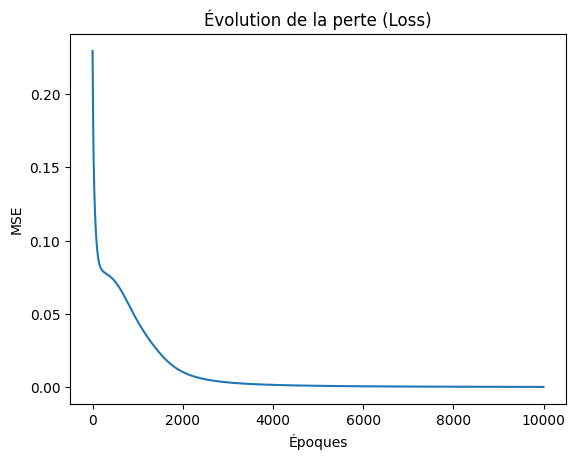

In [3]:
# Génération de données non-linéaires
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
y = y.reshape(-1, 1)

# Hyperparamètres
input_size = 2
hidden_size = 4
output_size = 1
learning_rate = 0.1
epochs = 10000

# Initialisation des poids
W1 = np.random.randn(input_size, hidden_size)
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size)
b2 = np.zeros((1, output_size))

losses = []

for i in range(epochs):
    # Forward pass
    z1 = np.dot(X, W1) + b1
    a1 = np.tanh(z1)
    z2 = np.dot(a1, W2) + b2
    a2 = sigmoid(z2)
    
    # Calcul de l'erreur (MSE)
    loss = np.mean((a2 - y)**2)
    losses.append(loss)
    
    # Backward pass
    dz2 = a2 - y
    dW2 = np.dot(a1.T, dz2)
    db2 = np.sum(dz2, axis=0, keepdims=True)
    
    dz1 = np.dot(dz2, W2.T) * (1 - np.power(a1, 2)) # Dérivée de tanh
    dW1 = np.dot(X.T, dz1)
    db1 = np.sum(dz1, axis=0, keepdims=True)
    
    # Mise à jour des poids
    W2 -= learning_rate * dW2 / len(X)
    b2 -= learning_rate * db2 / len(X)
    W1 -= learning_rate * dW1 / len(X)
    b1 -= learning_rate * db1 / len(X)

plt.plot(losses)
plt.title('Évolution de la perte (Loss)')
plt.xlabel('Époques')
plt.ylabel('MSE')
plt.show()

## 3. Niveau Intermédiaire : Keras / TensorFlow

Utilisation d'un framework pour construire des modèles plus complexes sur des données réelles.

### 3.1 Chargement et préparation des données (Iris)

Nous utilisons le dataset Iris pour une classification multi-classes.

In [4]:
iris = load_iris()
X_iris = iris.data
y_iris = tf.keras.utils.to_categorical(iris.target)

X_train, X_test, y_train, y_test = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 3.2 Architecture Dense + ReLU + Softmax

Construction d'un modèle séquentiel simple.

c:\Users\fofan\Documents\ML\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


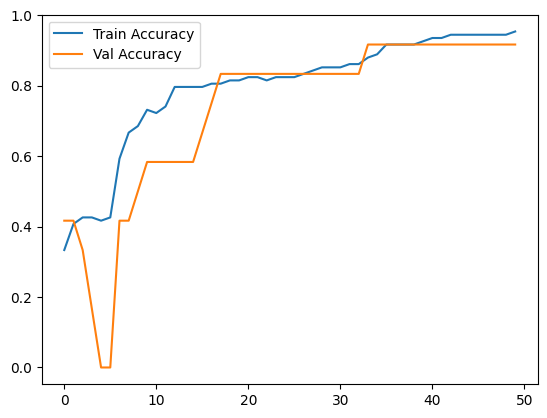

In [5]:
model = models.Sequential([
    layers.Dense(10, activation='relu', input_shape=(4,)),
    layers.Dense(10, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=50, batch_size=8, validation_split=0.1, verbose=0)

# Visualisation
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.show()

## 4. Niveau Avancé : Régularisation et Optimisation

Ajout de techniques pour améliorer la généralisation.

### 4.1 Dropout, Batch Norm et Early Stopping

Nous créons un modèle plus robuste.

In [6]:
model_adv = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(4,)),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model_adv.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history_adv = model_adv.fit(X_train, y_train, epochs=100, batch_size=8, 
                            validation_split=0.2, callbacks=[early_stop], verbose=0)

print('Entraînement terminé avec Early Stopping.')

Entraînement terminé avec Early Stopping.


## 5. Niveau Expert : Concepts Approfondis

Implémentation manuelle d'Adam et analyse des gradients.

### 5.1 Implémentation manuelle d'Adam

Comparaison conceptuelle de la mise à jour des poids.

In [7]:
def adam_update(w, g, m, v, t, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * (g**2)
    m_hat = m / (1 - beta1**t)
    v_hat = v / (1 - beta2**t)
    w = w - lr * m_hat / (np.sqrt(v_hat) + epsilon)
    return w, m, v

# Simulation d'une mise à jour
w, m, v = 0.5, 0, 0
g = 0.1 # gradient simulé
for t in range(1, 11):
    w, m, v = adam_update(w, g, m, v, t)
    print(f'Itération {t}: w = {w:.6f}')

Itération 1: w = 0.499000
Itération 2: w = 0.498000
Itération 3: w = 0.497000
Itération 4: w = 0.496000
Itération 5: w = 0.495000
Itération 6: w = 0.494000
Itération 7: w = 0.493000
Itération 8: w = 0.492000
Itération 9: w = 0.491000
Itération 10: w = 0.490000


## 6. Conclusion Pratique

- **Quand utiliser un réseau de neurones ?** Lorsque les données sont complexes, non-linéaires et abondantes.
- **Pièges à éviter :** Le sur-apprentissage (overfitting), un mauvais choix de taux d'apprentissage, et l'absence de normalisation des données.